# 4.9: Intro to Data Visualization with Python Part 2

In [2]:
# Importing libraries

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [3]:
# Create a path
path = '/Users/muhammaddildar/Desktop/03-2025 Instacart Basket Analysis'

In [4]:
# importing dataframe
df = pd.read_pickle(os.path.join(path, 'Data', 'Prepared Data', 'ords_prods_cust_merge.pkl'))

## Provide the Instacart senior stakeholders with descriptive findings about sales. Create a histogram of the “order_hour_of_day” column.

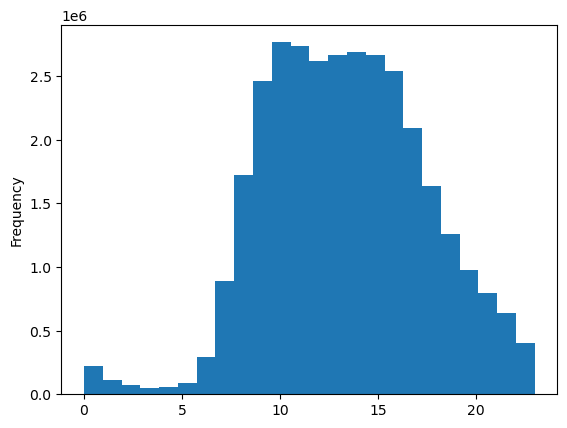

In [6]:
#creating histogram for 'order_hour_of_day'
hist = df['order_hour_of_day'].plot.hist(bins = 24)

#### The histogram reveals distinct peaks in the order frequency, highlighting the hours of the day when the highest number of orders are placed. If these peaks occur around midday or in the early evening, it could suggest that customers prefer to place their orders during lunch breaks or after work hours. The overall shape of the distribution can provide insights into whether orders are concentrated at certain times of day or spread evenly across all hours. A symmetrical distribution might indicate a consistent ordering pattern throughout the day, while a more uneven, skewed distribution could point to a preference for shopping during specific periods, such as the afternoon or evening.


## The marketing team is curious about the distribution of orders among customers in terms of loyalty. Create a bar chart from the “loyalty_flag” column

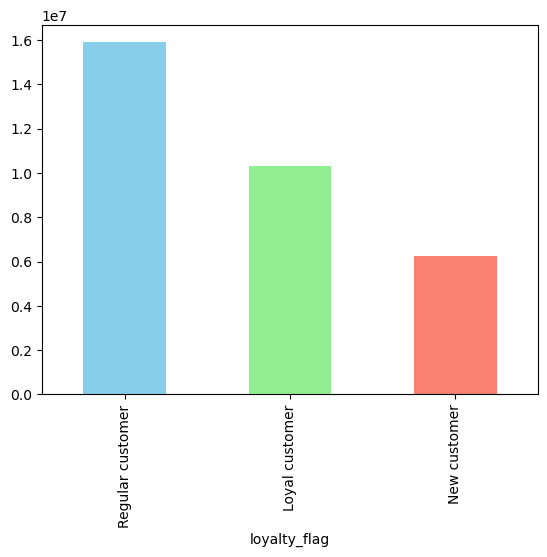

In [9]:
bar = df['loyalty_flag'].value_counts().plot.bar(color=['skyblue', 'lightgreen', 'salmon'])


## Checking the difference in expenditure by hour of day

In [11]:
#creating a sample of the dataframe
sampled_df = df.sample(n=500000, random_state=1)

In [12]:
#Group by hour of the day and calculate the mean expenditure
hourly_expenditure = sampled_df.groupby('order_hour_of_day')['prices'].mean().reset_index


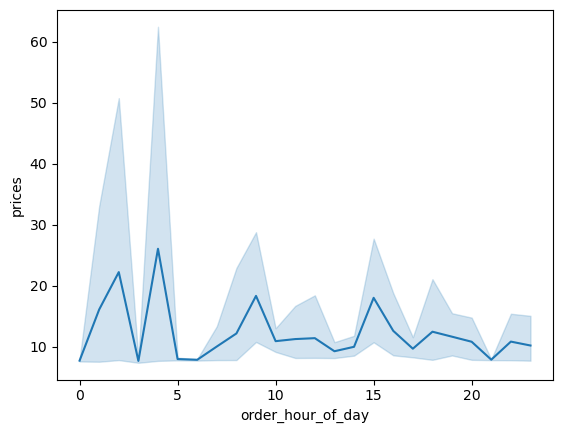

In [13]:
line_price_hod = sns.lineplot(data = sampled_df, x = 'order_hour_of_day', y = 'prices')

In [28]:
sampled_df['prices'].describe()

count    100000.000000
mean         12.016258
std         482.942913
min           1.000000
25%           4.200000
50%           7.400000
75%          11.200000
max       99999.000000
Name: prices, dtype: float64

### Connections between age and number of depentants

In [48]:
sampled_df.columns

Index(['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'product_id', 'add_to_cart_order',
       'reordered', '_merge', 'product_name', 'aisle_id', 'department_id',
       'prices', 'price_range_loc', 'busiest_day', 'busiest_day_updated',
       'slowest_day_updated', 'busiest_period_of_day', 'max_order',
       'loyalty_flag', 'avg_price', 'spending_flag', 'median_days',
       'order_frequency_flag', 'First Name', 'Last Name', 'Gender', 'State',
       'Age', 'Date Joined', 'Number of Dependents', 'Family Status',
       'Income'],
      dtype='object')

In [62]:
# Group by age and calculate the mean number of dependents
age_dependents = df.groupby('Age')['Number of Dependents'].mean().reset_index()

# Inspect the data
print(age_dependents.head())


   Age  Number of Dependents
0   18              1.506977
1   19              1.569480
2   20              1.478186
3   21              1.503765
4   22              1.472860


Text(0, 0.5, 'Average Number of Dependents')

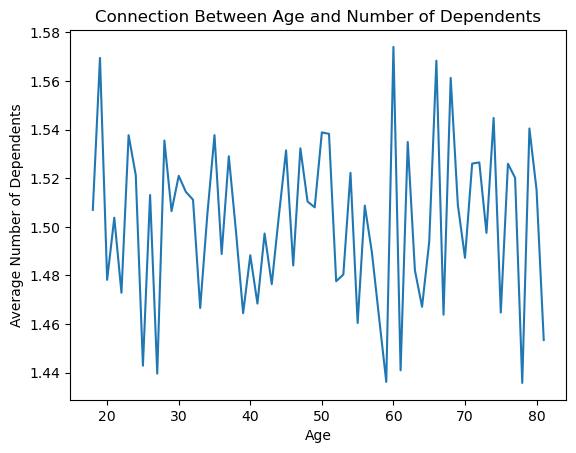

In [72]:
#Creating a line chart
line_age_dependents = sns.lineplot(data=age_dependents, x='Age', y='Number of Dependents')
line_age_dependents.set_title('Connection Between Age and Number of Dependents')
line_age_dependents.set_xlabel('Age')
line_age_dependents.set_ylabel('Average Number of Dependents')


### Connection Between Age and Number of Dependents

The line chart visualizes the relationship between a customer's **age** and the **average number of dependents** they have. From the chart, we can observe whether there is a trend in the number of dependents as customers age. 

- **Rising Dependents**: If the line shows an upward trend with age, it could suggest that older customers tend to have more dependents.
- **Flat Line**: If the line is relatively flat, it may indicate that the number of dependents does not significantly change with age.
- **Peaks/Valleys**: Any peaks or valleys might indicate specific age groups with a higher or lower number of dependents, which could be useful for targeted marketing efforts.

This information could help businesses tailor campaigns based on customer demographics, such as targeting younger customers who may have fewer dependents or older customers who may have larger families.


## Explore whether there’s a connection between age and spending power (income). To visualize this relationship, create a scatterplot. 

Text(0, 0.5, 'Income')

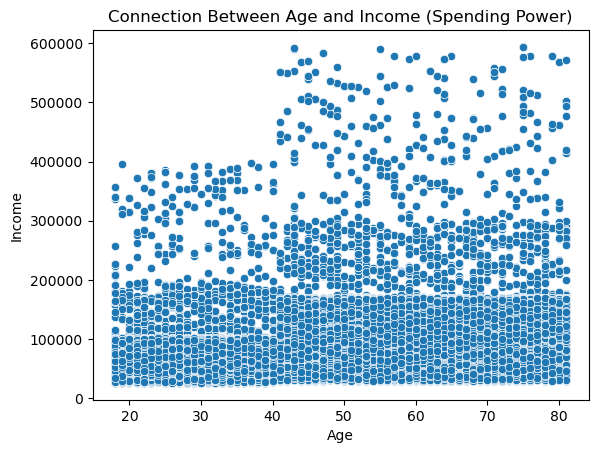

In [78]:
#creating a scatterplot of 'Age' and 'Income'
scatterplot = sns.scatterplot(x='Age', y='Income', data=sampled_df)
# Add title and labels for clarity
scatterplot.set_title('Connection Between Age and Income (Spending Power)')
scatterplot.set_xlabel('Age')
scatterplot.set_ylabel('Income')

### Connection Between Age and Income (Spending Power)

The scatterplot visualizes the relationship between a customer’s **age** and their **income**, which can be an indicator of spending power. The x-axis represents the **age** of the customers, while the y-axis represents their **income**.

- **Positive or Negative Trend**: If the points generally form an upward or downward trend, it would suggest a correlation between age and income. For example, older customers might have higher income due to longer work experience, or younger customers might have lower income due to entry-level positions.
- **No Clear Relationship**: If the points are scattered randomly across the plot, this might indicate that **income** does not strongly correlate with **age**.
- **Clusters or Outliers**: Any clusters or isolated points can provide additional insights. For example, certain age groups might have a higher density of customers with similar income, or there might be outliers with unusually high or low incomes for their age.

This analysis can help businesses understand the **spending power** of different age groups and allow them to tailor marketing campaigns accordingly.


In [81]:
#exporting and saving images
hist.figure.savefig(os.path.join(path, 'Analysis','Visualizations', 'hist_order_hour_of_day.png'))

In [83]:
#exporting and saving image
bar.figure.savefig(os.path.join(path, 'Analysis','Visualizations', 'bar_loyalty_flag.png'))

In [85]:
#exporting and saving image
line_price_hod.figure.savefig(os.path.join(path, 'Analysis','Visualizations', 'line_price_hour_of_day.png'))

In [87]:
#exporting and saving image
line_price_hod.figure.savefig(os.path.join(path, 'Analysis','Visualizations', 'line_price_hour_of_day.png'))

In [89]:
#exporting and saving image
scatterplot.figure.savefig(os.path.join(path, 'Analysis', 'Visualizations', 'scatter_age_income.png'))